# MBA Admission Predictor
# Problem Statement
# Predict whether an applicant will be Admitted or Denied using Logistic Regression


# 1. Data Understanding & Cleaning
## 2. Exploratory Data Analysis (EDA)
## 3. Feature Engineering
## 4. Model Training & Evaluation
## 5. Insights & Visualizations

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score
sns.set_style('whitegrid')

In [2]:
applications = pd.read_csv('applications.csv')
applications.isna().sum()


application_id       0
gender               0
international        0
gpa                  0
major                0
race              1842
gmat                 0
work_exp             0
work_industry        0
admission         5194
dtype: int64

In [3]:
applications['race'] = applications['race'].fillna('Unknown')
applications['admission'] = applications['admission'].fillna('Deny')
applications = applications[applications['admission'] != 'Waitlist']
applications['admission'].unique()


array(['Admit', 'Deny'], dtype=object)

In [4]:
applications['gender'] = applications['gender'].map({'Male':1, 'Female':0})
applications['admission'] = applications['admission'].map({'Admit':1, 'Deny':0})

applications.isna().sum()



application_id    0
gender            0
international     0
gpa               0
major             0
race              0
gmat              0
work_exp          0
work_industry     0
admission         0
dtype: int64

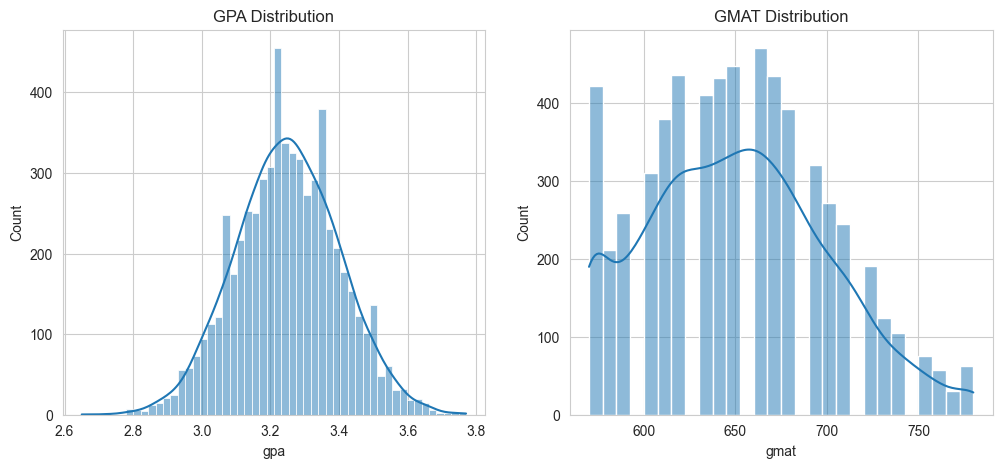

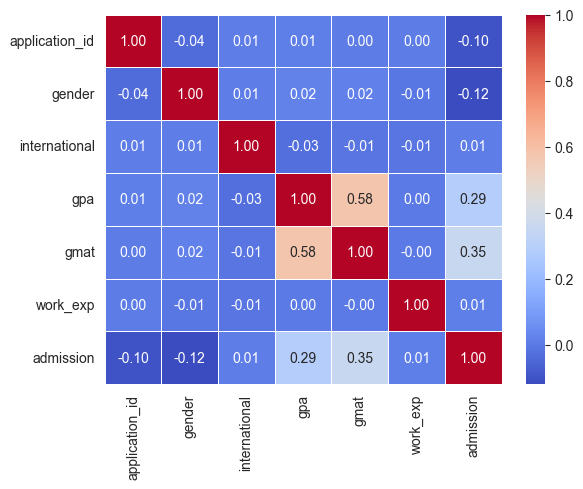

In [5]:
# Distribution of GPA and GMAT
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(applications['gpa'], kde=True, ax=ax[0])
ax[0].set_title('GPA Distribution')
sns.histplot(applications['gmat'], kde=True, ax=ax[1])
ax[1].set_title('GMAT Distribution')
plt.show()



real_gees = applications[['gender', 'international', 'gpa', 'major', 'race', 'gmat', 'work_exp', 'work_industry', 'admission']]
# df_encoded =  pd.get_dummies(real_gees, dtype=int)
corr = applications.corr(numeric_only=True)
sns.heatmap(data=corr, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm')
# plt.savefig('correlation.png')

plt.show()


In [6]:
X = applications.drop(['admission', 'application_id'], axis=1)  
X = pd.get_dummies(X, drop_first=True)   
y = applications[['admission']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

import joblib

joblib.dump(log_reg, 'log_reg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')  

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


Accuracy: 0.8433141919606235
Precision: 0.39622641509433965
Recall: 0.11666666666666667


c:\Users\HP\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Conclusion & Insights
- Accuracy: 84%
- Precision: 40%
- Recall: 12%

- Key drivers: GPA and GMAT are strongest predictors (from correlation).

In [7]:
applications.to_csv('applications_cleaned.csv', index=False)